# **Lab: Transfer Learning with Pre-trained Model using MNIST Dataset**
---
### **Handwritten Digit Classification using Google MobileNetV2 (Pre-trained on ImageNet)**
---
**Deep Learning & GenAI 2026-27 V-B**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

---
### **Objective:**
1. Understand the core principles of **Transfer Learning** and **Feature Extraction** with Deep Convolutional Neural Networks.
2. Adapt the **MNIST handwritten digit dataset** ($28 \times 28$ grayscale) for **Google MobileNetV2**, which requires 3-channel RGB inputs ($32 \times 32 \times 3$ minimum, upscaled to $64 \times 64 \times 3$).
3. Load the pre-trained **MobileNetV2** backbone trained on ImageNet weights, excluding its original 1000-class classifier.
4. Freeze the base model feature extractor weights to preserve learned low-level visual representations.
5. Attach a task-specific custom classification head (`Dropout(0.2)` $\to$ `Linear(1280, 128)` $\to$ `ReLU` $\to$ `Dropout(0.2)` $\to$ `Linear(128, 10)`).
6. Train the model using the **Adam Optimizer** and **Cross-Entropy Loss**.
7. Evaluate classification performance, plot **Loss & Accuracy Convergence Graphs**, display the **Confusion Matrix**, and visualize **Sample Predictions with Confidence Scores**.

## **1. Environment Setup & Library Imports**
We import PyTorch and Torchvision for building the Transfer Learning pipeline, NumPy for numeric processing, and Matplotlib for rich visual analysis.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from sklearn.metrics import confusion_matrix, classification_report

# Visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version:     {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")
print(f"Execution Device:    {device}")

PyTorch Version:     2.14.0+cpu
Torchvision Version: 0.29.0+cpu
Execution Device:    cpu


## **2. Dataset Loading & Preprocessing for MobileNetV2**
The MNIST dataset consists of $28 \times 28$ grayscale images across 10 digit classes ($0-9$).
Since Google MobileNetV2 expects 3-channel RGB images:
1. **Resize:** Upscale images from $28 \times 28$ to $64 \times 64$ for optimal spatial resolution.
2. **Channel Expansion:** Convert 1-channel Grayscale to 3-channel RGB (`Grayscale(num_output_channels=3)`).
3. **ImageNet Normalization:** Standardize pixel values using ImageNet mean ($[0.485, 0.456, 0.406]$) and std ($[0.229, 0.224, 0.225]$).

In [2]:
# Define transformation pipeline tailored for MobileNetV2
mobilenet_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Download and load MNIST dataset
train_dataset_full = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=mobilenet_transforms
)

test_dataset_full = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=mobilenet_transforms
)

# Use a well-sized subset for quick, efficient transfer learning demonstration
TRAIN_SIZE = 8000
TEST_SIZE = 2000

train_dataset = Subset(train_dataset_full, range(TRAIN_SIZE))
test_dataset = Subset(test_dataset_full, range(TEST_SIZE))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training Samples: {len(train_dataset)}")
print(f"Test Samples:     {len(test_dataset)}")
print(f"Batch Size:       {BATCH_SIZE}")
print(f"Transformed Image Shape: (3, 64, 64)")

Training Samples: 8000
Test Samples:     2000
Batch Size:       64
Transformed Image Shape: (3, 64, 64)


## **3. Exploratory Data Visualization**
Let us inspect sample transformed MNIST digits alongside their true class labels.

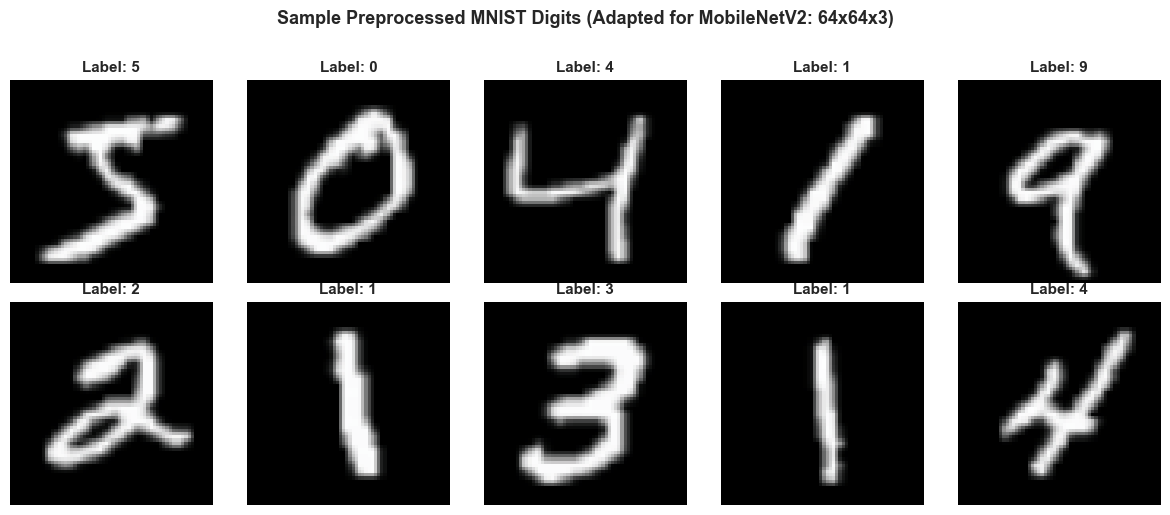

In [3]:
# Inverse transform for display
inv_mean = np.array([0.485, 0.456, 0.406])
inv_std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Preprocessed MNIST Digits (Adapted for MobileNetV2: 64x64x3)", fontsize=13, fontweight='bold', y=1.02)

for idx in range(10):
    ax = axes.flat[idx]
    img, lbl = train_dataset[idx]
    
    # Denormalize image: (C, H, W) -> (H, W, C)
    img_np = img.permute(1, 2, 0).numpy() * inv_std + inv_mean
    img_np = np.clip(img_np, 0, 1)
    
    ax.imshow(img_np)
    ax.set_title(f"Label: {lbl}", fontsize=11, fontweight='semibold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## **4. MobileNetV2 Architecture & Transfer Learning Model**
### **A. Base Model (Google MobileNetV2)**
- **Architecture:** Depthwise Separable Convolutions with Inverted Residual Blocks and Linear Bottlenecks.
- **Pre-trained Weights:** ImageNet (1.4 million images, 1000 categories).
- **Weight Freezing:** Freeze base feature extraction layers to preserve learned general visual features.

### **B. Custom Classification Head**
- **Input Features:** $1280$ (from MobileNetV2 feature extractor)
- **Classifier Architecture:**
  - `Dropout(0.2)`
  - `Linear(1280, 128)`
  - `ReLU()`
  - `Dropout(0.2)`
  - `Linear(128, 10)` (Outputs logits for 10 digit classes $0-9$)

In [4]:
# 1. Load Pre-trained MobileNetV2 with default ImageNet weights
weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)

# 2. Freeze lower feature extraction layers (0-14) and unfreeze top layers (15-18)
for i, layer in enumerate(model.features):
    if i < 15:
        for param in layer.parameters():
            param.requires_grad = False
    else:
        for param in layer.parameters():
            param.requires_grad = True

# 3. Replace classification head with custom digit classifier
in_features = model.last_channel  # 1280
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(128, 10)
)

model = model.to(device)

# Count Trainable vs Frozen Parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total Parameters:     {total_params:,}")
print(f"Frozen Parameters:    {frozen_params:,} (Base Feature Extractor)")
print(f"Trainable Parameters: {trainable_params:,} (Top Inverted Residual Blocks + Custom Head)")
print("-" * 50)
print(model.classifier)

Total Parameters:     2,389,130
Frozen Parameters:    697,792 (Base Feature Extractor)
Trainable Parameters: 1,691,338 (Top Inverted Residual Blocks + Custom Head)
--------------------------------------------------
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=128, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=128, out_features=10, bias=True)
)


## **5. Model Training (Transfer Learning)**
We train the model using **Cross-Entropy Loss** and the **Adam Optimizer**.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': [p for i, layer in enumerate(model.features) if i >= 15 for p in layer.parameters()], 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
])

EPOCHS = 5
train_loss_hist = []
train_acc_hist = []
val_loss_hist = []
val_acc_hist = []

print("Starting Training (Transfer Learning with Pre-trained MobileNetV2)...\n")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100.0
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100.0
    
    train_loss_hist.append(epoch_train_loss)
    train_acc_hist.append(epoch_train_acc)
    val_loss_hist.append(epoch_val_loss)
    val_acc_hist.append(epoch_val_acc)
    
    elapsed = time.time() - start_time
    print(f"Epoch [{epoch}/{EPOCHS}] ({elapsed:.1f}s) - "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

Starting Training (Transfer Learning with Pre-trained MobileNetV2)...

Epoch [1/5] (23.2s) - Train Loss: 0.9760 | Train Acc: 70.04% | Val Loss: 0.4980 | Val Acc: 83.60%
Epoch [2/5] (22.0s) - Train Loss: 0.3766 | Train Acc: 88.05% | Val Loss: 0.3659 | Val Acc: 88.20%
Epoch [3/5] (22.9s) - Train Loss: 0.2307 | Train Acc: 92.12% | Val Loss: 0.3384 | Val Acc: 90.05%
Epoch [4/5] (21.9s) - Train Loss: 0.1698 | Train Acc: 94.61% | Val Loss: 0.2904 | Val Acc: 91.65%
Epoch [5/5] (21.2s) - Train Loss: 0.1249 | Train Acc: 96.05% | Val Loss: 0.2928 | Val Acc: 91.15%


## **6. Model Evaluation & Performance Metrics**
We evaluate the final trained model on the full test set, obtaining predictions, per-class Precision, Recall, and F1-Score.

In [6]:
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

final_acc = np.mean(all_preds == all_labels) * 100.0
print("=" * 45)
print(f"Final Test Accuracy: {final_acc:.2f}%")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

Final Test Accuracy: 91.15%

Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.9351    0.9886    0.9611       175
           1     0.9625    0.9872    0.9747       234
           2     0.8810    0.8447    0.8625       219
           3     0.8333    0.8937    0.8625       207
           4     0.9234    0.9447    0.9339       217
           5     0.9379    0.8436    0.8882       179
           6     0.9419    0.9101    0.9257       178
           7     0.8884    0.9317    0.9095       205
           8     0.9037    0.8802    0.8918       192
           9     0.9194    0.8814    0.9000       194

    accuracy                         0.9115      2000
   macro avg     0.9127    0.9106    0.9110      2000
weighted avg     0.9121    0.9115    0.9112      2000



## **7. Visualization: Convergence & Accuracy Curves**
We visualize the **Loss Progression** and **Accuracy Curves** across training and validation epochs.

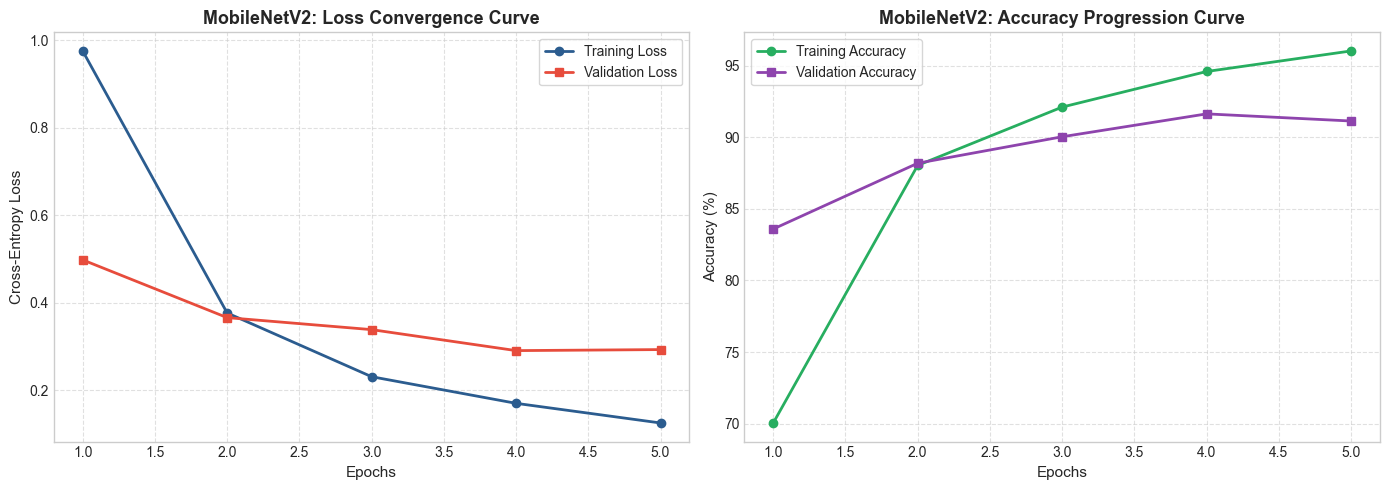

In [7]:
plt.figure(figsize=(14, 5))

# Plot 1: Loss Convergence
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_loss_hist, marker='o', linewidth=2, color='#2b5c8f', label='Training Loss')
plt.plot(range(1, EPOCHS + 1), val_loss_hist, marker='s', linewidth=2, color='#e74c3c', label='Validation Loss')
plt.title('MobileNetV2: Loss Convergence Curve', fontsize=13, fontweight='bold')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Cross-Entropy Loss', fontsize=11)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy Progression
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_acc_hist, marker='o', linewidth=2, color='#27ae60', label='Training Accuracy')
plt.plot(range(1, EPOCHS + 1), val_acc_hist, marker='s', linewidth=2, color='#8e44ad', label='Validation Accuracy')
plt.title('MobileNetV2: Accuracy Progression Curve', fontsize=13, fontweight='bold')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## **8. Confusion Matrix Heatmap**
The confusion matrix highlights true vs. predicted digit distribution across all 10 classes.

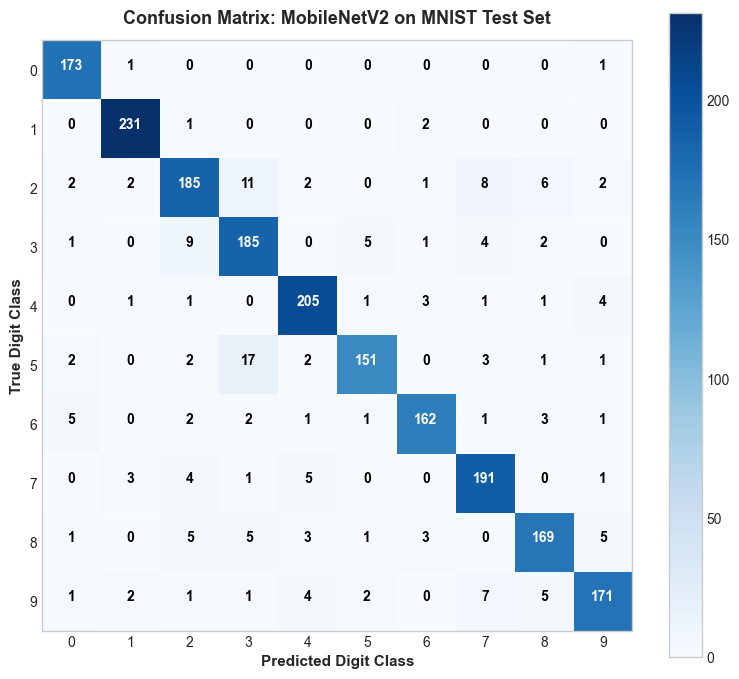

In [8]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix: MobileNetV2 on MNIST Test Set', fontsize=13, fontweight='bold', pad=12)
plt.colorbar(im)
tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks, fontsize=10)
plt.yticks(tick_marks, tick_marks, fontsize=10)

# Add numeric annotations inside cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=10, fontweight='bold')

plt.ylabel('True Digit Class', fontsize=11, fontweight='semibold')
plt.xlabel('Predicted Digit Class', fontsize=11, fontweight='semibold')
plt.grid(False)
plt.tight_layout()
plt.show()

## **9. Sample Test Predictions with Confidence Scores**
We visualize randomly selected test images alongside their True Label, Predicted Label, and Softmax Confidence.

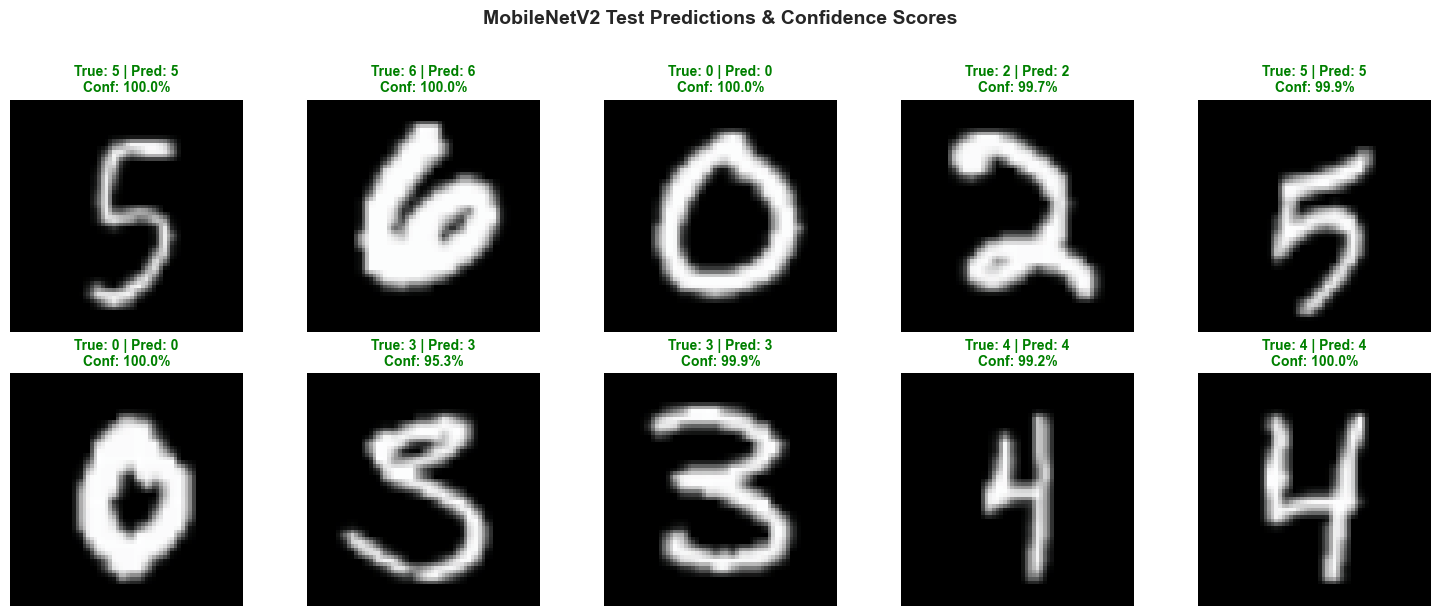

In [9]:
indices = np.random.choice(len(test_dataset), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("MobileNetV2 Test Predictions & Confidence Scores", fontsize=14, fontweight='bold', y=1.02)

for i, idx in enumerate(indices):
    ax = axes.flat[i]
    img, true_lbl = test_dataset[idx]
    pred_lbl = all_preds[idx]
    conf = all_probs[idx][pred_lbl] * 100.0
    
    # Denormalize image for display
    img_np = img.permute(1, 2, 0).numpy() * inv_std + inv_mean
    img_np = np.clip(img_np, 0, 1)
    
    color = 'green' if true_lbl == pred_lbl else 'red'
    
    ax.imshow(img_np)
    ax.set_title(f"True: {true_lbl} | Pred: {pred_lbl}\nConf: {conf:.1f}%", fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()